In [1]:
import os,csv,re
import pandas as pd
import numpy as np
import scanpy as sc
import math
import SpaGCN as spg
from scipy.sparse import issparse
import random, torch
import warnings
warnings.filterwarnings("ignore")
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import SpaGCN as spg
import cv2

In [2]:
i=674

In [3]:
adata = sc.read_10x_h5(f"/home/dbj/mouse/DLPFC/DLPFC/151{i}/filtered_feature_bc_matrix.h5")
adata.var_names_make_unique()
spatial=pd.read_csv(f"/home/dbj/mouse/DLPFC/DLPFC/151{i}/spatial/tissue_positions_list.csv",sep=",",header=None,na_filter=False,index_col=0) 
adata.obs["x1"]=spatial[1]
adata.obs["x2"]=spatial[2]
adata.obs["x3"]=spatial[3]
adata.obs["x4"]=spatial[4]
adata.obs["x5"]=spatial[5]
#Select captured samples
adata=adata[adata.obs["x1"]==1]
adata.var_names=[i.upper() for i in list(adata.var_names)]
adata.var["genename"]=adata.var.index.astype("str")

img=cv2.imread(f"/home/dbj/cellvelo/DFPLC_FULLIMAGE/151{i}_full_image.tif")
adata.obs["x_array"]=adata.obs["x2"]
adata.obs["y_array"]=adata.obs["x3"]
adata.obs["x_pixel"]=adata.obs["x4"]
adata.obs["y_pixel"]=adata.obs["x5"]
x_array=adata.obs["x_array"].tolist()
y_array=adata.obs["y_array"].tolist()
x_pixel=adata.obs["x_pixel"].tolist()
y_pixel=adata.obs["y_pixel"].tolist()

#Test coordinates on the image
img_new=img.copy()
for i in range(len(x_pixel)):
    x=x_pixel[i]
    y=y_pixel[i]
    img_new[int(x-20):int(x+20), int(y-20):int(y+20),:]=0

cv2.imwrite('./sample_results/151673_map.jpg', img_new)

False

In [4]:
s=1
b=49
adj=spg.calculate_adj_matrix(x=x_pixel,y=y_pixel, x_pixel=x_pixel, y_pixel=y_pixel, image=img, beta=b, alpha=s, histology=True)

Calculateing adj matrix using histology image...
Var of c0,c1,c2 =  40.6795174981594 347.0641903760143 56.49545287887716
Var of x,y,z =  5859121.663035659 4365852.6924909325 5859121.663035658


In [5]:
adata.var_names_make_unique()
spg.prefilter_genes(adata,min_cells=3) # avoiding all genes are zeros
spg.prefilter_specialgenes(adata)
#Normalize and take log for UMI
sc.pp.normalize_per_cell(adata)
sc.pp.log1p(adata)

In [6]:
p=0.5 
#Find the l value given p
l=spg.search_l(p, adj, start=0.01, end=1000, tol=0.01, max_run=100)

Run 1: l [0.01, 1000], p [0.0, 167.5242445017212]
Run 2: l [0.01, 500.005], p [0.0, 33.776824951171875]
Run 3: l [0.01, 250.0075], p [0.0, 5.615477561950684]
Run 4: l [0.01, 125.00874999999999], p [0.0, 0.7440891265869141]
Run 5: l [62.509375, 125.00874999999999], p [0.04294753074645996, 0.7440891265869141]
Run 6: l [93.7590625, 125.00874999999999], p [0.2783529758453369, 0.7440891265869141]
Run 7: l [109.38390625, 125.00874999999999], p [0.48020660877227783, 0.7440891265869141]
Run 8: l [109.38390625, 117.196328125], p [0.48020660877227783, 0.6040799617767334]
Run 9: l [109.38390625, 113.29011718749999], p [0.48020660877227783, 0.5401653051376343]
recommended l =  111.33701171874999


In [8]:
n_clusters=7
#Set seed
r_seed=t_seed=n_seed=200
#Seaech for suitable resolution
res=spg.search_res(adata, adj, l, n_clusters, start=0.7, step=0.1, tol=5e-3, lr=0.05, max_epochs=20, r_seed=r_seed, t_seed=t_seed, n_seed=n_seed)

Start at res =  0.7 step =  0.1
Initializing cluster centers with louvain, resolution =  0.7
Epoch  0
Epoch  10
Res =  0.7 Num of clusters =  7
recommended res =  0.7


In [9]:
clf=spg.SpaGCN()
clf.set_l(l)
#Set seed
random.seed(r_seed)
torch.manual_seed(r_seed)
np.random.seed(r_seed)
clf.train(adata,adj,init_spa=True,init="louvain",res=res, tol=5e-3, lr=0.05, max_epochs=200)
y_pred, prob=clf.predict()
adata.obs["pred"]= y_pred
adata.obs["pred"]=adata.obs["pred"].astype('category')
#Do cluster refinement(optional)
#shape="hexagon" for Visium data, "square" for ST data.
adj_2d=spg.calculate_adj_matrix(x=x_array,y=y_array, histology=False)
refined_pred=spg.refine(sample_id=adata.obs.index.tolist(), pred=adata.obs["pred"].tolist(), dis=adj_2d, shape="hexagon")
adata.obs["refined_pred"]=refined_pred
adata.obs["refined_pred"]=adata.obs["refined_pred"].astype('category')

Initializing cluster centers with louvain, resolution =  0.7
Epoch  0
Epoch  10
Epoch  20
Epoch  30
Epoch  40
Epoch  50
delta_label  0.004628369180506398 < tol  0.005
Reach tolerance threshold. Stopping training.
Total epoch: 55
Calculateing adj matrix using xy only...


In [10]:
adata.obs["pred"]= spg.detect_spatial_domains_ez_mode(adata, img, x_array, y_array, x_pixel, y_pixel, n_clusters=7, histology=True, s=1, b=49, p=0.5, r_seed=100, t_seed=100, n_seed=100)
adata.obs["pred"]=adata.obs["pred"].astype('category')
#Refine domains (optional)
#shape="hexagon" for Visium data, "square" for ST data.
adata.obs["refined_pred"]=spg.spatial_domains_refinement_ez_mode(sample_id=adata.obs.index.tolist(), pred=adata.obs["pred"].tolist(), x_array=x_array, y_array=y_array, shape="hexagon")
adata.obs["refined_pred"]=adata.obs["refined_pred"].astype('category')

Calculateing adj matrix using histology image...
Var of c0,c1,c2 =  40.6795174981594 347.0641903760143 56.49545287887716
Var of x,y,z =  5859121.663035659 4365852.6924909325 5859121.663035658
Run 1: l [0.01, 1000], p [0.0, 167.5242445017212]
Run 2: l [0.01, 500.005], p [0.0, 33.776824951171875]
Run 3: l [0.01, 250.0075], p [0.0, 5.615477561950684]
Run 4: l [0.01, 125.00874999999999], p [0.0, 0.7440891265869141]
Run 5: l [62.509375, 125.00874999999999], p [0.04294753074645996, 0.7440891265869141]
Run 6: l [93.7590625, 125.00874999999999], p [0.2783529758453369, 0.7440891265869141]
Run 7: l [109.38390625, 125.00874999999999], p [0.48020660877227783, 0.7440891265869141]
Run 8: l [109.38390625, 117.196328125], p [0.48020660877227783, 0.6040799617767334]
Run 9: l [109.38390625, 113.29011718749999], p [0.48020660877227783, 0.5401653051376343]
recommended l =  111.33701171874999
Start at res =  0.7 step =  0.1
Initializing cluster centers with louvain, resolution =  0.7
Epoch  0
Epoch  10
Res

In [11]:
i=674

In [12]:
adata2=sc.read_visium(f'/home/dbj/mouse/DLPFC/DLPFC/151{i}/')
adata.var_names_make_unique()
truth = pd.read_csv(f'/home/dbj/mouse/vision/spatial/DLPFC_annotations/151{i}_truth.csv', sep='\t', index_col=0)

# 将 truth 的某一列赋值到 adata.obs 中
adata2.obs['truth'] = truth.iloc[:,0]
adata2 = adata2[~adata2.obs['truth'].isna(), :]

In [13]:
adata2.obs['domain']=adata.obs['refined_pred']

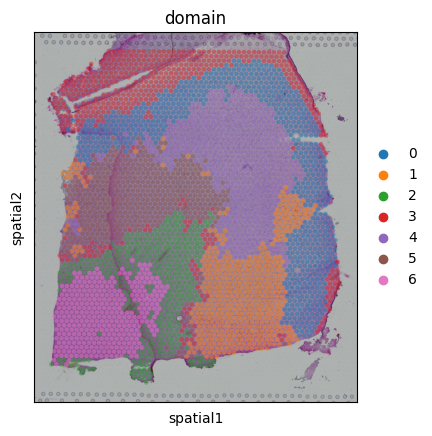

In [14]:
sc.pl.spatial(adata2, color='domain', img_key='hires', alpha=0.5, size=1.3)

In [15]:
from sklearn.metrics import adjusted_rand_score,normalized_mutual_info_score
ari = adjusted_rand_score(adata2.obs['truth'], adata2.obs['domain'])
nmi = normalized_mutual_info_score(adata2.obs['truth'], adata2.obs['domain'])
ari,nmi

(0.34706695372956947, 0.5057182968033583)